# Notebook 3 — TrOCR Fine-Tuning (Line-Level)

Segments each prescription image into lines (same horizontal-projection
algorithm validated in `data_enhancement.ipynb` §7), pairs each line crop
with its corresponding `field: value` segment from the ground-truth, and
fine-tunes TrOCR at the **line level** instead of feeding the full
prescription image. Reports both per-line CER and a full-prescription
CER aggregated back from line predictions.


## 1. Setup


In [20]:
%matplotlib inline
import os, sys, json, random, re, csv, warnings, time
from collections import defaultdict
import torch
import cv2
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, get_linear_schedule_with_warmup

try:
    import jiwer
except ImportError:
    jiwer = None
    print('[WARN] jiwer not installed — CER/WER metrics unavailable')

# --- KAGGLE PATH ADAPTATIONS ---
KAGGLE_BASE_DIR = '/kaggle/input/datasets/benhammadilokmane/processed/processed'
MAPPING_CSV     = os.path.join(KAGGLE_BASE_DIR, 'image_annotations.csv')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

KNOWN_FIELDS = [
    'doctor_name', 'clinic_name', 'clinic_address',
    'patient_name', 'patient_age', 'date',
    'medications', 'signature',
]

def strip_ocr(t):
    return re.sub(r'\s+', ' ', t.replace('<s_ocr>', '').replace('</s>', '')).strip()

def split_text_by_fields(text):
    """Split a cleaned ground-truth string into one 'field: value' segment
    per known field, in the order they appear."""
    pattern = '(' + '|'.join(KNOWN_FIELDS) + r'):\s*'
    parts = re.split(pattern, text)
    segments = []
    for i in range(1, len(parts), 2):
        field = parts[i]
        value = parts[i + 1].strip() if i + 1 < len(parts) else ''
        if value:
            segments.append(f'{field}: {value}')
    return segments

def detect_line_bboxes(pil_img, min_height=15):
    """Horizontal-projection line detection."""
    gray = np.array(pil_img.convert('L'))
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    h_proj = np.sum(binary, axis=1)
    bboxes, in_line, start = [], False, 0
    for y, val in enumerate(h_proj):
        if val > 0 and not in_line:
            in_line, start = True, y
        elif val == 0 and in_line:
            if y - start >= min_height:
                bboxes.append((start, y))
            in_line = False
    if in_line and pil_img.height - start >= min_height:
        bboxes.append((start, pil_img.height))
    return bboxes

def load_samples_from_csv(csv_path=MAPPING_CSV, sources=('processed', 'augmented')):
    """Load image-level samples adapted for the Kaggle directory structure."""
    if not os.path.isfile(csv_path):
        raise FileNotFoundError(
            f'{csv_path} not found. Please verify the Kaggle dataset path and CSV filename.')
    samples = []
    with open(csv_path, encoding='utf-8') as f:
        for row in csv.DictReader(f):
            if row['source'] not in sources:
                continue
            
            img_filename = os.path.basename(row['image_path'])
            ann_filename = os.path.basename(row['annotation_path'])
            img_path = os.path.join(KAGGLE_BASE_DIR, img_filename)
            ann_path = os.path.join(KAGGLE_BASE_DIR, ann_filename)
            
            samples.append({
                'id': os.path.splitext(img_filename)[0],
                'image_path': img_path,
                'annotation_path': ann_path,
                'text': row['ground_truth_clean'] or strip_ocr(row['ground_truth_raw']),
            })
    return samples

def build_line_samples(samples, min_height=15, max_count_diff=2):
    """Expand image-level samples into line-level samples."""
    line_samples = []
    skipped = 0
    for s in tqdm(samples, desc='Building line samples'):
        try:
            with Image.open(s['image_path']) as im:
                img = im.convert('RGB')
                bboxes = detect_line_bboxes(img, min_height=min_height)
        except Exception:
            skipped += 1
            continue
        
        gt_lines = split_text_by_fields(s['text'])
        if not bboxes or not gt_lines:
            skipped += 1
            continue
        if abs(len(bboxes) - len(gt_lines)) > max_count_diff:
            skipped += 1
            continue
        
        n = min(len(bboxes), len(gt_lines))
        origin = re.sub(r'_aug\d+$', '', s['id'])
        for i in range(n):
            top, bot = bboxes[i]
            line_samples.append({
                'id': f"{s['id']}_L{i}",
                'origin': origin,
                'image_path': s['image_path'],
                'top': int(top),
                'bottom': int(bot),
                'text': gt_lines[i],
            })
    return line_samples, skipped

def make_splits(samples, train_ratio=0.8, val_ratio=0.1, seed=42):
    """Group-aware split keyed on `origin`."""
    by_origin = {}
    for s in samples:
        origin = s.get('origin') or re.sub(r'_aug\d+$', '', s['id'])
        by_origin.setdefault(origin, []).append(s)
    
    origins = sorted(by_origin.keys())
    random.Random(seed).shuffle(origins)
    
    n = len(origins)
    tr = int(n * train_ratio)
    va = int(n * val_ratio)
    
    train, val, test = [], [], []
    for o in origins[:tr]:        train.extend(by_origin[o])
    for o in origins[tr:tr+va]:   val.extend(by_origin[o])
    for o in origins[tr+va:]:     test.extend(by_origin[o])
    return train, val, test

class PrescriptionLineDataset(Dataset):
    """Yields a single line crop + its target text."""
    def __init__(self, samples, processor, max_length=128):
        self.samples = samples
        self.processor = processor
        self.max_length = max_length
        
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        s = self.samples[idx]
        img = Image.open(s['image_path']).convert('RGB')
        crop = img.crop((0, s['top'], img.width, s['bottom']))
        pv = self.processor(images=crop, return_tensors='pt').pixel_values.squeeze(0)
        
        text = s['text']
        labels = self.processor.tokenizer(text, padding='max_length',
                    max_length=self.max_length, truncation=True,
                    return_tensors='pt').input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        
        return {'pixel_values': pv, 'labels': labels, 'text': text}

class PrescriptionOCR(torch.nn.Module):
    def __init__(self, model_name='microsoft/trocr-small-handwritten'):
        super().__init__()
        self.processor = TrOCRProcessor.from_pretrained(model_name)
        self.model = VisionEncoderDecoderModel.from_pretrained(model_name)
        self.model.config.decoder_start_token_id = self.processor.tokenizer.cls_token_id
        self.model.config.pad_token_id = self.processor.tokenizer.pad_token_id
        self.model.config.eos_token_id = self.processor.tokenizer.sep_token_id
        self.model.config.max_length = 128
        
    def forward(self, pixel_values, labels=None):
        return self.model(pixel_values=pixel_values, labels=labels)
        
    def generate(self, pixel_values, max_length=128, num_beams=4):
        ids = self.model.generate(pixel_values, max_length=max_length, num_beams=num_beams)
        return self.processor.batch_decode(ids, skip_special_tokens=True)
        
    def save(self, path):
        os.makedirs(path, exist_ok=True)
        self.model.save_pretrained(path)
        self.processor.save_pretrained(path)
        
    @classmethod
    def load(cls, path):
        obj = cls.__new__(cls)
        torch.nn.Module.__init__(obj)
        obj.processor = TrOCRProcessor.from_pretrained(path)
        obj.model = VisionEncoderDecoderModel.from_pretrained(path)
        return obj

def compute_cer(preds, refs):
    if jiwer is None: return float('nan')
    return jiwer.cer(refs, preds)

def compute_word_accuracy(preds, refs):
    if jiwer is None: return float('nan')
    return 1.0 - jiwer.wer(refs, preds)

warnings.filterwarnings('ignore', category=FutureWarning)
print('Setup complete')
print(f'Mapping CSV: {MAPPING_CSV}  (exists={os.path.isfile(MAPPING_CSV)})')

[WARN] jiwer not installed — CER/WER metrics unavailable
Setup complete
Mapping CSV: /kaggle/input/datasets/benhammadilokmane/processed/processed/image_annotations.csv  (exists=True)


## 2. Device & VRAM Check


In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    free, total = torch.cuda.mem_get_info()
    print(f'VRAM: {free/1e9:.2f} GB free / {total/1e9:.2f} GB total')
    if free / 1e9 < 3.0:
        print('[WARNING] < 3 GB free — close other GPU apps before training')

Device: cuda
GPU: Tesla T4
VRAM: 11.58 GB free / 15.64 GB total


## 3. Baseline — Pretrained TrOCR (Before Fine-Tuning)

Run the off-the-shelf model on a couple of processed images, **segmenting
each into lines first** and decoding line by line. Mirrors how we'll feed
data during fine-tuning so the comparison stays apples-to-apples.


In [24]:
model_name = 'microsoft/trocr-base-handwritten'
baseline_processor = TrOCRProcessor.from_pretrained(model_name)
baseline_model = VisionEncoderDecoderModel.from_pretrained(model_name).to(device)
baseline_model.eval()

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

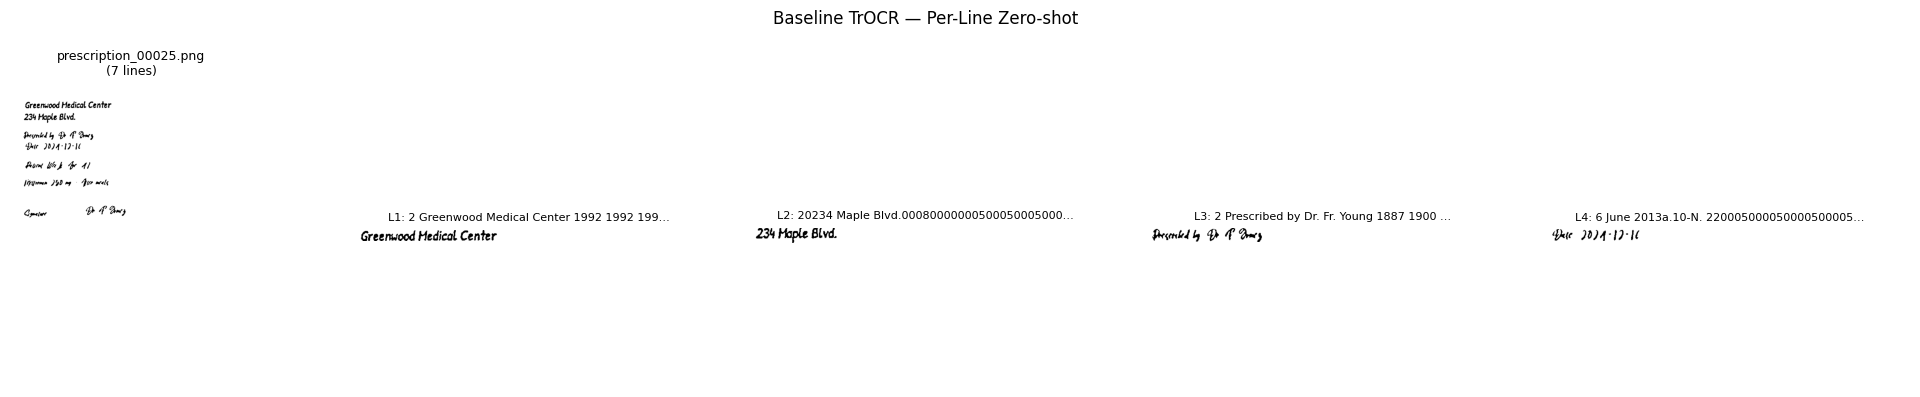

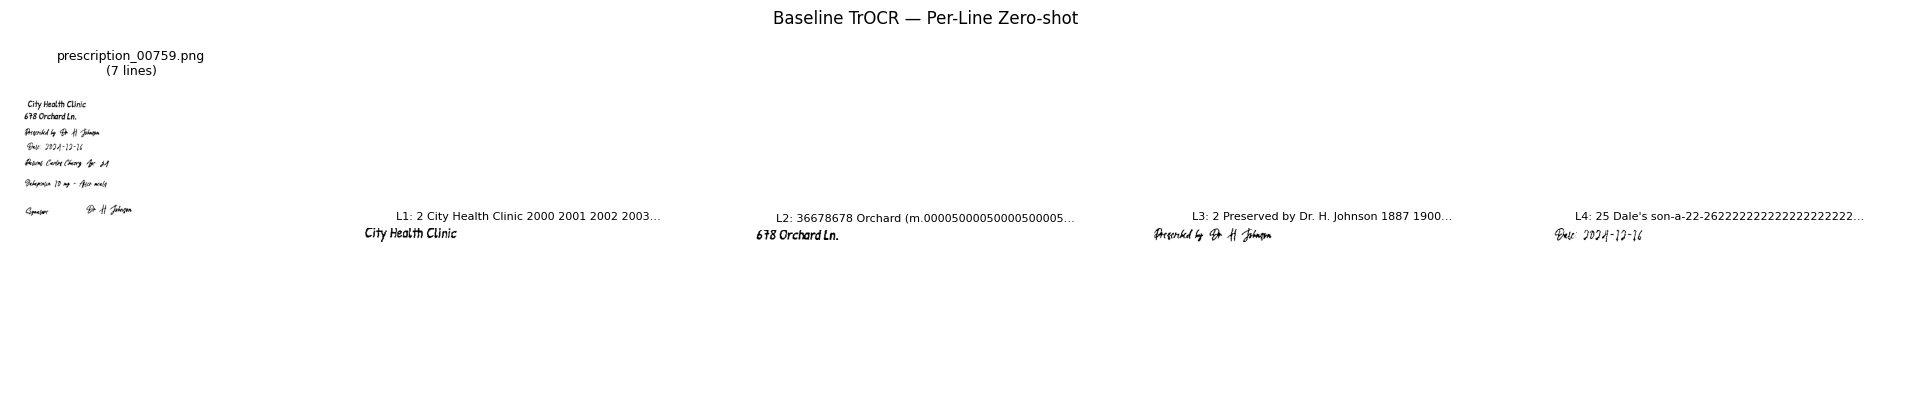


prescription_00025.png:
  L1: 2 Greenwood Medical Center 1992 1992 1992
  L2: 20234 Maple Blvd.00080000000500050005000
  L3: 2 Prescribed by Dr. Fr. Young 1887 1900 1900 1900
  L4: 6 June 2013a.10-N. 220005000050000500005
  L5: " Powers Who's for AT.00080000000000000000000
  L6: # Difference 950 mg . One male 3/ 3/ 3/
  L7: 2 September 1951 Dr. Ferreig1950 1951-0002200022

prescription_00759.png:
  L1: 2 City Health Clinic 2000 2001 2002 2003
  L2: 36678678 Orchard (m.00005000050000500005000050000500005000050000500005000050000500005000050000500005
  L3: 2 Preserved by Dr. H. Johnson 1887 1900
  L4: 25 Dale's son-a-22-26222222222222222222222222222222222222222222
  L5: 2 Robert Curtis Cherry Age , dated October 25 1892
  L6: 6 . Buhaporton ID no. After nearly 1 000 000 000 000 000 000
  L7: 2 Signature 2 . Dr. H. Johnson 3/ 3/ 3/


In [25]:
IMAGES_DIR = os.path.join(KAGGLE_BASE_DIR, 'images')
all_img_files = sorted(f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg')))
chosen = random.sample(all_img_files, min(2, len(all_img_files)))

baseline_examples = []
for fname in chosen:
    img = Image.open(os.path.join(IMAGES_DIR, fname)).convert('RGB')
    bboxes = detect_line_bboxes(img)
    line_preds = []
    
    for top, bot in bboxes:
        crop = img.crop((0, top, img.width, bot))
        pv = baseline_processor(images=crop, return_tensors='pt').pixel_values.to(device)
        with torch.no_grad():
            ids = baseline_model.generate(pv, max_length=128)
        line_preds.append(baseline_processor.batch_decode(ids, skip_special_tokens=True)[0])
        
    baseline_examples.append({'file': fname, 'image': img, 'bboxes': bboxes, 'lines': line_preds})

for ex in baseline_examples:
    img, bboxes = ex['image'], ex['bboxes']
    n_show = min(4, len(bboxes))
    fig, axes = plt.subplots(1, 1 + n_show, figsize=(4 * (1 + n_show), 4))
    
    axes[0].imshow(np.array(img))
    axes[0].set_title(f'{ex["file"]}\n({len(bboxes)} lines)', fontsize=9)
    axes[0].axis('off')
    
    for j in range(n_show):
        top, bot = bboxes[j]
        axes[j + 1].imshow(np.array(img.crop((0, top, img.width, bot))))
        axes[j + 1].set_title(f'L{j+1}: {ex["lines"][j][:40]}…', fontsize=8, wrap=True)
        axes[j + 1].axis('off')
        
    plt.suptitle('Baseline TrOCR — Per-Line Zero-shot', fontsize=12)
    plt.tight_layout()
    plt.show()

for ex in baseline_examples:
    print(f'\n{ex["file"]}:')
    for i, line in enumerate(ex['lines']):
        print(f'  L{i+1}: {line[:100]}')

## 4. Build Line-Level Dataset & Splits

Expand each preprocessed/augmented image into one sample per detected
line, paired with the matching `field: value` segment from the ground-truth.
Splits are grouped by `origin` so every variant and every line of the
same source image lives in exactly one split.


In [11]:
samples = load_samples_from_csv(MAPPING_CSV, sources=('processed', 'augmented'))
n_proc = sum(1 for s in samples if '_aug' not in s['id'])
n_aug  = len(samples) - n_proc
print(f'Image-level samples: {len(samples)}  (processed: {n_proc}, augmented: {n_aug})')

line_samples, skipped = build_line_samples(samples, min_height=15, max_count_diff=2)
print(f'Line-level samples : {len(line_samples)}')
print(f'Skipped images     : {skipped}  (line/field count mismatch or unreadable)')

train_samples, val_samples, test_samples = make_splits(line_samples)
print(f'Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}')

s0 = train_samples[0]
print(f'Example image : {os.path.basename(s0["image_path"])}  rows {s0["top"]}–{s0["bottom"]}')
print(f'Example label : {s0["text"]}')

Image-level samples: 3000  (processed: 1000, augmented: 2000)


Building line samples: 100%|██████████| 3000/3000 [00:40<00:00, 74.24it/s]

Line-level samples : 8328
Skipped images     : 1917  (line/field count mismatch or unreadable)
Train: 6637 | Val: 861 | Test: 830
Example image : prescription_00873.png  rows 57–83
Example label : doctor_name: Dr. M. Lee


## 5. DataLoaders


In [12]:
processor = TrOCRProcessor.from_pretrained('microsoft/trocr-small-handwritten')

train_ds = PrescriptionLineDataset(train_samples, processor, max_length=128)
val_ds   = PrescriptionLineDataset(val_samples,   processor, max_length=128)
test_ds  = PrescriptionLineDataset(test_samples,  processor, max_length=128)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

batch = next(iter(train_loader))
print(f'pixel_values : {batch["pixel_values"].shape}')
print(f'labels       : {batch["labels"].shape}')
print(f'Batch OK ✓')

pixel_values : torch.Size([8, 3, 384, 384])
labels       : torch.Size([8, 128])
Batch OK ✓


## 6. Model Setup


In [13]:
ocr = PrescriptionOCR(model_name='microsoft/trocr-small-handwritten').to(device)

total_p  = sum(p.numel() for p in ocr.parameters() if p.requires_grad)
enc_p    = sum(p.numel() for p in ocr.model.encoder.parameters() if p.requires_grad)
dec_p    = sum(p.numel() for p in ocr.model.decoder.parameters() if p.requires_grad)
print(f'Trainable params — Total: {total_p:,}  |  Encoder: {enc_p:,}  |  Decoder: {dec_p:,}')


Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-small-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params — Total: 61,596,672  |  Encoder: 21,960,192  |  Decoder: 39,636,480


## 7. Training Loop (5 Epochs, fp16)

AdamW + linear warmup + GradScaler. Tracks per-batch loss, epoch loss,
val CER, val word accuracy, and learning rate.


In [14]:
EPOCHS = 5
LR = 5e-5

optimizer = AdamW(ocr.parameters(), lr=LR, weight_decay=0.01)
total_steps = EPOCHS * len(train_loader)
warmup_steps = max(1, int(0.1 * total_steps))
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

use_fp16 = device.type == 'cuda'
scaler = GradScaler(enabled=use_fp16)

train_losses, val_cers, val_word_accs = [], [], []
batch_losses, lr_history = [], []
best_cer = float('inf')

for epoch in range(1, EPOCHS + 1):
    # ---- train ----
    ocr.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}')
    for batch in pbar:
        pv = batch['pixel_values'].to(device)
        lb = batch['labels'].to(device)
        optimizer.zero_grad()
        with autocast(enabled=use_fp16):
            out = ocr(pv, labels=lb)
            loss = out.loss
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(ocr.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        batch_losses.append(loss.item())
        epoch_loss += loss.item()
        lr_history.append(scheduler.get_last_lr()[0])
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ---- validate (line-level CER) ----
    ocr.eval()
    preds, refs = [], []
    with torch.no_grad():
        for batch in val_loader:
            pv = batch['pixel_values'].to(device)
            ids = ocr.model.generate(pv, max_length=128)
            preds.extend(ocr.processor.batch_decode(ids, skip_special_tokens=True))
            refs.extend(batch['text'])

    cer = compute_cer(preds, refs)
    wacc = compute_word_accuracy(preds, refs)
    val_cers.append(cer)
    val_word_accs.append(wacc)

    if cer < best_cer:
        best_cer = cer
        save_dir = os.path.join(ROOT, 'checkpoints', 'best_model')
        ocr.save(save_dir)
        print(f'  ★ New best line-CER={cer:.4f} — saved to {save_dir}')

    print(f'  Epoch {epoch}: loss={avg_loss:.4f}  line-CER={cer:.4f}  WordAcc={wacc:.4f}')

    if device.type == 'cuda':
        alloc = torch.cuda.memory_allocated() / 1e9
        print(f'  VRAM allocated: {alloc:.2f} GB')


Epoch 1/5:   0%|          | 0/830 [00:00<?, ?it/s]/tmp/ipykernel_55/2626372342.py:33: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Epoch 1/5:  57%|█████▋    | 470/830 [01:12<00:55,  6.50it/s, loss=0.4957]


KeyboardInterrupt: 

## 8. Training Curves


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
epochs_ax = range(1, len(train_losses) + 1)

axes[0, 0].plot(epochs_ax, train_losses, 'o-')
axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Epoch')

axes[0, 1].plot(epochs_ax, val_cers, 'o-', color='tab:red')
axes[0, 1].set_title('Validation CER')
axes[0, 1].set_xlabel('Epoch')

axes[1, 0].plot(epochs_ax, val_word_accs, 'o-', color='tab:green')
axes[1, 0].set_title('Validation Word Accuracy')
axes[1, 0].set_xlabel('Epoch')

axes[1, 1].plot(batch_losses, alpha=0.5, linewidth=0.5)
axes[1, 1].set_title('Per-Batch Loss')
axes[1, 1].set_xlabel('Step')

plt.tight_layout()
plt.show()

# LR schedule
plt.figure(figsize=(7, 3))
plt.plot(lr_history)
plt.title('Learning Rate Schedule')
plt.xlabel('Step')
plt.ylabel('LR')
plt.tight_layout()
plt.show()


## 9. Evaluation on Validation Lines

Show 6 random line crops from validation along with predicted text,
ground-truth text, and per-line CER.


In [ ]:
ocr.eval()
eval_subset = random.sample(val_samples, min(6, len(val_samples)))

fig, axes = plt.subplots(3, 2, figsize=(16, 9))
for ax, s in zip(axes.flatten(), eval_subset):
    img = Image.open(s['image_path']).convert('RGB')
    crop = img.crop((0, s['top'], img.width, s['bottom']))
    pv = processor(images=crop, return_tensors='pt').pixel_values.to(device)
    with torch.no_grad():
        ids = ocr.model.generate(pv, max_length=128)
    pred = processor.batch_decode(ids, skip_special_tokens=True)[0]
    ref = s['text']
    sample_cer = compute_cer([pred], [ref])

    ax.imshow(np.array(crop))
    ax.set_title(f'CER={sample_cer:.3f}\nGT  : {ref[:60]}\nPred: {pred[:60]}', fontsize=8)
    ax.axis('off')

plt.suptitle('Validation Line Predictions (Fine-Tuned)', fontsize=13)
plt.tight_layout()
plt.show()


## 10. Test Set Evaluation

Final held-out evaluation. We report **line-level CER** (the metric the
model was trained against) and **full-prescription CER** obtained by
joining all line predictions of the same origin image back together.


In [ ]:
ocr.eval()
test_preds, test_refs = [], []
t0 = time.time()

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Test inference'):
        pv = batch['pixel_values'].to(device)
        ids = ocr.model.generate(pv, max_length=128)
        test_preds.extend(processor.batch_decode(ids, skip_special_tokens=True))
        test_refs.extend(batch['text'])

elapsed = time.time() - t0
test_cer = compute_cer(test_preds, test_refs)
test_wacc = compute_word_accuracy(test_preds, test_refs)

# Aggregate per-origin to get a full-prescription CER as well.
by_origin_pred = defaultdict(list)
by_origin_ref  = defaultdict(list)
for s, p, r in zip(test_samples, test_preds, test_refs):
    by_origin_pred[s['origin']].append(p)
    by_origin_ref[s['origin']].append(r)

origins = list(by_origin_pred.keys())
full_preds = [' '.join(by_origin_pred[o]) for o in origins]
full_refs  = [' '.join(by_origin_ref[o])  for o in origins]
full_cer  = compute_cer(full_preds, full_refs)
full_wacc = compute_word_accuracy(full_preds, full_refs)

print('═' * 48)
print(f'  Line-level CER             : {test_cer:.4f}')
print(f'  Line-level Word Accuracy   : {test_wacc:.4f}')
print(f'  Test lines                 : {len(test_preds)}')
print(f'  Inference time             : {elapsed:.1f}s ({elapsed/len(test_preds):.2f}s/line)')
print('-' * 48)
print(f'  Full-prescription CER      : {full_cer:.4f}')
print(f'  Full-prescription Word Acc : {full_wacc:.4f}')
print(f'  Distinct prescriptions     : {len(origins)}')
print('═' * 48)


## 11. Before vs After Comparison


In [ ]:
# Pick a few distinct origin images from val and run both models on
# every line of each, then join the lines for a full-image comparison.
val_by_origin = defaultdict(list)
for s in val_samples:
    val_by_origin[s['origin']].append(s)
chosen_origins = random.sample(list(val_by_origin.keys()),
                               min(4, len(val_by_origin)))

rows = []
for origin in chosen_origins:
    lines = sorted(val_by_origin[origin], key=lambda s: s['top'])
    img = Image.open(lines[0]['image_path']).convert('RGB')

    base_lines, ft_lines, ref_lines = [], [], []
    for ls in lines:
        crop = img.crop((0, ls['top'], img.width, ls['bottom']))
        pv_b = baseline_processor(images=crop, return_tensors='pt').pixel_values.to(device)
        pv_f = processor(images=crop, return_tensors='pt').pixel_values.to(device)
        with torch.no_grad():
            ids_b = baseline_model.generate(pv_b, max_length=128)
            ids_f = ocr.model.generate(pv_f, max_length=128)
        base_lines.append(baseline_processor.batch_decode(ids_b, skip_special_tokens=True)[0])
        ft_lines.append(processor.batch_decode(ids_f, skip_special_tokens=True)[0])
        ref_lines.append(ls['text'])

    pred_b = ' '.join(base_lines)
    pred_f = ' '.join(ft_lines)
    ref = ' '.join(ref_lines)
    cer_b = compute_cer([pred_b], [ref])
    cer_f = compute_cer([pred_f], [ref])
    rows.append([origin, f'{cer_b:.3f}', f'{cer_f:.3f}',
                 ref[:50] + '…', pred_b[:50] + '…', pred_f[:50] + '…'])

headers = ['Image', 'CER (base)', 'CER (fine-tuned)', 'Ground Truth', 'Baseline', 'Fine-Tuned']
try:
    from tabulate import tabulate
    print(tabulate(rows, headers=headers, tablefmt='github'))
except ImportError:
    print('\t'.join(headers))
    for r in rows:
        print('\t'.join(r))


## 12. Save Final Model


In [ ]:
save_dir = os.path.join(ROOT, 'checkpoints', 'best_model')
ocr.save(save_dir)
print(f'Model saved to: {save_dir}')
print('Files:', os.listdir(save_dir)[:8])
